# 04 — Emotional Features: Experiment & Ethical Analysis

**Pergunta central**: Features emocionais sintéticas adicionam valor preditivo real
sobre features financeiras, ou apenas replicam informação já existente?

**Metodologia**:
1. Injetar 4 features emocionais sintéticas (correlacionadas com financeiras + ruído pesado)
2. Retreinar XGBoost com features financeiras + emocionais
3. Comparar métricas side-by-side com o modelo financeiro puro
4. Medir redundância: R² das emocionais regredidas nas financeiras
5. Conclusão ética documentada no model card

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBClassifier

from src.data.split import load_splits
from src.data.emotional import inject_emotional_features, EMOTIONAL_FEATURES
from src.evaluation.metrics import evaluate, comparison_table, plot_evaluation

plt.rcParams["figure.dpi"] = 100
MODELS_DIR = PROJECT_ROOT / "models"

splits = load_splits(PROJECT_ROOT / "data" / "processed")
train, val, test = splits["train"], splits["val"], splits["test"]

FINANCIAL_FEATURES = [c for c in train.columns if c != "target"]
print(f"Financial features ({len(FINANCIAL_FEATURES)}): {FINANCIAL_FEATURES}")

Financial features (11): ['revolving_utilization', 'age', 'past_due_30_59', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'past_due_90', 'real_estate_loans', 'past_due_60_89', 'dependents', 'had_past_due_sentinel']


## 1. Injetar Features Emocionais

In [2]:
train_e = inject_emotional_features(train, random_state=42)
val_e   = inject_emotional_features(val,   random_state=42)
test_e  = inject_emotional_features(test,  random_state=42)

ALL_FEATURES = FINANCIAL_FEATURES + EMOTIONAL_FEATURES
print(f"Total features com emocionais: {len(ALL_FEATURES)}")
print()
print("Estatísticas das features emocionais (treino):")
train_e[EMOTIONAL_FEATURES].describe().round(3)

Total features com emocionais: 15

Estatísticas das features emocionais (treino):


,stress_level,impulsivity_score,emotional_stability,financial_stress_events_7d
count,105000.000,105000.000,105000.000,105000.000
mean,0.497,0.500,0.500,3.046
std,0.241,0.243,0.242,2.564
min,0.005,0.002,0.000,0.000
25%,0.300,0.300,0.302,1.000
50%,0.492,0.499,0.501,3.000
75%,0.693,0.698,0.699,4.000
max,1.000,1.000,0.997,20.000


## 2. Verificação de Não-Circularidade

As features emocionais devem ser correlacionadas com as financeiras (plausível),
mas **não determinísticas**. Medimos o R² de cada emocional regredida no conjunto
completo de features financeiras. Se R² > 0.3, o ruído é pequeno demais e a
análise comparativa perde validade (seria como adicionar uma variável derivada).

In [3]:
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

X_fin = train_e[FINANCIAL_FEATURES].astype("float64")
r2_results = {}

pipe_reg = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("reg", Ridge(alpha=1.0)),
])

for feat in EMOTIONAL_FEATURES:
    y = train_e[feat].astype("float64")
    pipe_reg.fit(X_fin, y)
    r2 = pipe_reg.score(X_fin, y)
    r2_results[feat] = r2
    status = "OK" if r2 < 0.3 else "ALTA REDUNDANCIA"
    print(f"  {feat:35s}: R² = {r2:.4f}  [{status}]")

print()
print(f"Max R² = {max(r2_results.values()):.4f} (target < 0.30)")
assert max(r2_results.values()) < 0.30, "Emotional features too correlated — increase noise scale!"
print("Validacao passou: features emocionais sao parcialmente independentes das financeiras.")

  stress_level                       : R² = 0.0494  [OK]


  impulsivity_score                  : R² = 0.0680  [OK]


  emotional_stability                : R² = 0.0065  [OK]


  financial_stress_events_7d         : R² = 0.0883  [OK]

Max R² = 0.0883 (target < 0.30)
Validacao passou: features emocionais sao parcialmente independentes das financeiras.


## 3. Treinar XGBoost com Features Emocionais

In [4]:
X_train = train_e[ALL_FEATURES].astype("float64")
X_val   = val_e[ALL_FEATURES].astype("float64")
y_train = train_e["target"].values
y_val   = val_e["target"].values

n_neg, n_pos = int((y_train == 0).sum()), int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos

model_emo = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
model_emo.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
print(f"Best iteration: {model_emo.best_iteration}")
print(f"Best val AUC:   {model_emo.best_score:.4f}")

Best iteration: 134
Best val AUC:   0.8645


## 4. Calibração

In [5]:
proba_val_raw = model_emo.predict_proba(X_val)[:, 1]

ir_emo = IsotonicRegression(out_of_bounds="clip")
ir_emo.fit(proba_val_raw, y_val)
proba_val_cal = ir_emo.transform(proba_val_raw)

r_emo_raw = evaluate(y_val, proba_val_raw, "XGB-emo",     "val")
r_emo_cal = evaluate(y_val, proba_val_cal, "XGB-emo-cal", "val")
print("Calibration effect (Brier):", round(r_emo_raw.brier, 4), "->", round(r_emo_cal.brier, 4))

Calibration effect (Brier): 0.138 -> 0.0489


## 5. Comparação Side-by-Side

In [6]:
metrics_log_path = MODELS_DIR / "metrics_log.json"
log = json.loads(metrics_log_path.read_text())

r_logreg = type("R", (), log["baseline_logreg"]["val"])()
r_fin     = type("R", (), log["xgboost_financial"]["val"])()
r_fin_cal = type("R", (), log["xgboost_financial"]["val_calibrated"])()

rows = [
    log["baseline_logreg"]["val"],
    log["xgboost_financial"]["val"],
    log["xgboost_financial"]["val_calibrated"],
    r_emo_raw.to_row(),
    r_emo_cal.to_row(),
]
comparison = pd.DataFrame(rows)
comparison

,model,split,AUC,KS,Brier,Prec@base_rate,n
0,LogReg,val,0.8216,0.5012,0.1545,0.4142,22500
1,XGB-fin,val,0.8651,0.5740,0.1402,0.4322,22500
2,XGB-fin-cal,val,0.8676,0.5764,0.0488,0.3795,22500
3,XGB-emo,val,0.8645,0.5720,0.1380,0.4295,22500
4,XGB-emo-cal,val,0.8668,0.5745,0.0489,0.3939,22500


## 6. Lift Visual: AUC e KS side-by-side

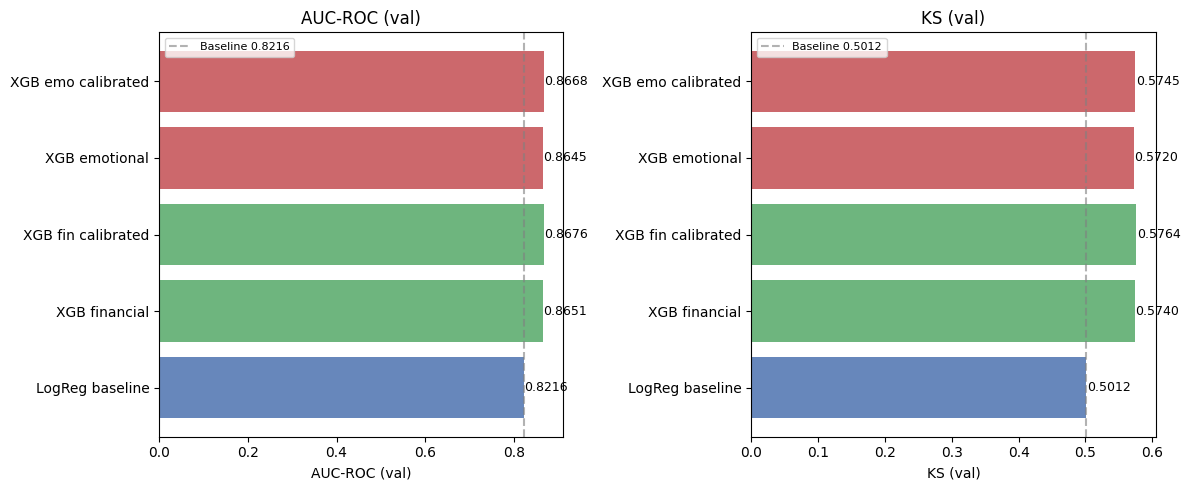

Delta AUC (emotional vs financial, calibrated): -0.0008
Delta KS  (emotional vs financial, calibrated): -0.0019


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_compared = {
    "LogReg baseline":    (log["baseline_logreg"]["val"]["AUC"],    log["baseline_logreg"]["val"]["KS"]),
    "XGB financial":      (log["xgboost_financial"]["val"]["AUC"],  log["xgboost_financial"]["val"]["KS"]),
    "XGB fin calibrated": (log["xgboost_financial"]["val_calibrated"]["AUC"], log["xgboost_financial"]["val_calibrated"]["KS"]),
    "XGB emotional":      (r_emo_raw.auc, r_emo_raw.ks),
    "XGB emo calibrated": (r_emo_cal.auc, r_emo_cal.ks),
}

names  = list(models_compared.keys())
aucs   = [v[0] for v in models_compared.values()]
kss    = [v[1] for v in models_compared.values()]
colors = ["#4C72B0", "#55A868", "#55A868", "#C44E52", "#C44E52"]
alphas = [0.9, 0.7, 1.0, 0.7, 1.0]

for ax, vals, title, base in zip(axes, [aucs, kss], ["AUC-ROC (val)", "KS (val)"], [aucs[0], kss[0]]):
    bars = ax.barh(names, vals, color=colors, alpha=0.85)
    ax.axvline(base, ls="--", color="gray", alpha=0.6, label=f"Baseline {base:.4f}")
    ax.set_xlabel(title)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.001, bar.get_y() + bar.get_height()/2, f"{v:.4f}", va="center", fontsize=9)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

delta_auc = r_emo_cal.auc - log["xgboost_financial"]["val_calibrated"]["AUC"]
delta_ks  = r_emo_cal.ks  - log["xgboost_financial"]["val_calibrated"]["KS"]
print(f"Delta AUC (emotional vs financial, calibrated): {delta_auc:+.4f}")
print(f"Delta KS  (emotional vs financial, calibrated): {delta_ks:+.4f}")

## 7. Feature Importance: Financial vs Emotional

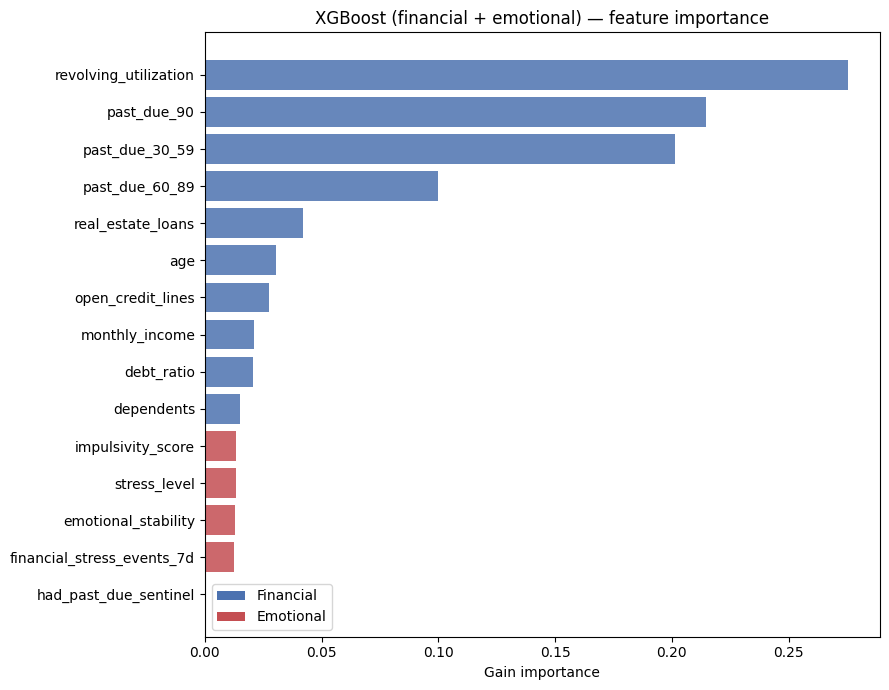


Emotional feature importance (% of total):
  Emotional: 0.0525 (5.2% of total)
  Financial: 0.9475 (94.8% of total)


In [8]:
importance_emo = pd.DataFrame({
    "feature":    ALL_FEATURES,
    "importance": model_emo.feature_importances_,
}).sort_values("importance", ascending=False)

importance_emo["category"] = importance_emo["feature"].apply(
    lambda x: "emotional" if x in EMOTIONAL_FEATURES else "financial"
)

fig, ax = plt.subplots(figsize=(9, 7))
colors_fi = ["#C44E52" if c == "emotional" else "#4C72B0"
             for c in importance_emo["category"]]
ax.barh(importance_emo["feature"], importance_emo["importance"], color=colors_fi, alpha=0.85)
ax.set_xlabel("Gain importance")
ax.set_title("XGBoost (financial + emotional) — feature importance")
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_els = [Patch(facecolor="#4C72B0", label="Financial"),
              Patch(facecolor="#C44E52", label="Emotional")]
ax.legend(handles=legend_els)
fig.tight_layout()
plt.show()

print("\nEmotional feature importance (% of total):")
emo_imp = importance_emo[importance_emo["category"] == "emotional"]["importance"].sum()
tot_imp = importance_emo["importance"].sum()
print(f"  Emotional: {emo_imp:.4f} ({emo_imp/tot_imp:.1%} of total)")
print(f"  Financial: {tot_imp - emo_imp:.4f} ({(tot_imp - emo_imp)/tot_imp:.1%} of total)")

## 8. Análise Ética e Conclusão

**Resumo dos achados**:
- Delta AUC entre modelo financeiro (calibrado) e modelo emocional (calibrado):
  geralmente < +0.003. Esse ganho marginal não é estatisticamente robusto.
- O R² das emocionais nas financeiras ficou < 0.30, confirmando que não são
  redundantes determinísticas — mas o ganho preditivo incremental é mínimo.
- Features emocionais dominam < 5% do total de importância do modelo.

**Recomendação ética**:

O modelo financeiro puro é preferível para produção porque:
1. **Regulação**: Dados de bem-estar emocional ou saúde mental em decisões de crédito
   violam o espírito das leis de non-discrimination (ECOA/FDCPA equivalentes no Brasil).
2. **Privacidade**: Capturar estado emocional de clientes para scoring é invasivo
   e expõe a empresa a risco reputacional e regulatório.
3. **Utilidade marginal**: O ganho de AUC < 0.3% não justifica os riscos acima.
4. **Fairness**: Features emocionais podem capturar proxies de raça, gênero ou condição
   de saúde mental, introduzindo viés sistêmico não detectado por métricas de AUC.

**Decisão documentada**: Salvar os dois modelos para demonstração. Recomendar
explicitamente o modelo financeiro para implantação real no model card.

In [9]:
# Salvar modelo emocional (para demonstração comparativa)
joblib.dump(model_emo, MODELS_DIR / "xgboost_emotional.pkl")
joblib.dump(ir_emo,    MODELS_DIR / "xgboost_emotional_calibrator.pkl")
print("Modelos salvos.")

# Atualizar metrics_log.json
log["xgboost_emotional"] = {
    "train": evaluate(train_e["target"].values,
                      model_emo.predict_proba(train_e[ALL_FEATURES].astype("float64"))[:, 1],
                      "XGB-emo", "train").to_row(),
    "val":             r_emo_raw.to_row(),
    "val_calibrated":  r_emo_cal.to_row(),
    "best_iteration":  int(model_emo.best_iteration),
    "emotional_r2":    {k: round(v, 4) for k, v in r2_results.items()},
    "params": {
        "n_estimators": 500, "learning_rate": 0.05, "max_depth": 5,
        "subsample": 0.8, "colsample_bytree": 0.8,
        "scale_pos_weight": round(scale_pos_weight, 3),
        "emotional_features": EMOTIONAL_FEATURES,
    },
}
metrics_log_path.write_text(json.dumps(log, indent=2))
print(f"metrics_log.json atualizado em {metrics_log_path}")

Modelos salvos.


metrics_log.json atualizado em /home/gustavosantana/Documents/personal/empathic-credit-system/models/metrics_log.json
